In [4]:
# %% [markdown]
# # 01 - Data Preprocessing
# **Project:** AI-Based Media Empathy Analyzer  
# **Objective:** Parse raw screenplay `.txt` files, extract structured dialogues, clean text, and perform exploratory data analysis (EDA).
# 
# *This notebook is formatted using the standard `# %%` cell markers for seamless integration into Jupyter and VS Code environments.*

# %% [markdown]
# ## 1. Imports

# %%
import re
import warnings
from collections import Counter
from pathlib import Path
from typing import List, Dict, Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Suppress minor warnings for clean output
warnings.filterwarnings('ignore')

# %% [markdown]
# ## 2. Configuration

# %%
# Define base directory using a raw string for Windows path compatibility
BASE_DIR = Path(r"D:\project\NLP")

# Define dependent directory paths
RAW_DATA_DIR = BASE_DIR / "data" / "raw_scripts"
PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"
OUTPUT_FILE = PROCESSED_DATA_DIR / "dialogues.csv"

# Create processed directory if it doesn't exist
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# %% [markdown]
# ## 3. Functions

# %%
def is_page_number_or_copyright(line: str) -> bool:
    """
    Detects if a line is a page number, formatting artifact, or copyright text.
    
    Args:
        line (str): The text line to evaluate.
        
    Returns:
        bool: True if the line matches unwanted patterns, False otherwise.
    """
    # Page numbers like '1.', '1', '(1)', '[1]'
    if re.match(r'^(?:\d{1,3}\.?|\[?\d{1,3}\]?|\(\d{1,3}\))$', line):
        return True
    
    # Copyright or rights text
    if re.search(r'(copyright|©|all rights reserved)', line, re.IGNORECASE):
        return True
        
    return False

def clean_character_name(line: str) -> str:
    """
    Cleans a character name line by stripping parentheticals (e.g., (V.O.), (CONT'D)).
    
    Args:
        line (str): The raw character name line.
        
    Returns:
        str: The cleaned character name.
    """
    # Remove parenthetical extensions like (V.O.) or (CONT'D)
    cleaned = re.sub(r'\(.*?\)', '', line).strip()
    # Remove unwanted trailing/leading punctuation
    cleaned = re.sub(r'[^A-Z0-9\s\-/]', '', cleaned).strip()
    return cleaned

def clean_dialogue_text(text: str) -> str:
    """
    Cleans dialogue by lowercasing, removing extra spaces, and preserving NLP punctuation.
    
    Args:
        text (str): The raw dialogue text.
        
    Returns:
        str: The cleaned dialogue text.
    """
    # Remove inline parentheticals (usually actor directions like '(sighs)')
    text = re.sub(r'\(.*?\)', '', text)
    # Lowercase
    text = text.lower()
    # Preserve only alphanumeric, spaces, and punctuation useful for NLP (. , ! ? ' ")
    text = re.sub(r'[^a-z0-9\s\.,!\?\'\"]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def parse_screenplay(file_path: Path) -> List[Dict[str, str]]:
    """
    Parses a screenplay text file and extracts structured dialogues.
    
    Automatically detects scene headings, character names, and dialogue,
    while implicitly ignoring action/scene descriptions based on screenplay structure.
    
    Args:
        file_path (Path): Path to the `.txt` screenplay file.
        
    Returns:
        List[Dict[str, str]]: A list of dictionaries containing Movie, Scene, Character, and Dialogue.
    """
    extracted_data = []
    movie_name = file_path.stem
    current_scene = "UNKNOWN_SCENE"
    current_character: Optional[str] = None
    current_dialogue_block: List[str] = []

    try:
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()
    except Exception as e:
        print(f"Error reading {file_path.name}: {e}")
        return []

    for line in lines:
        line = line.strip()

        # 1. Handle empty lines (used to denote the end of a speaking or action block)
        if not line:
            if current_character and current_dialogue_block:
                extracted_data.append({
                    'Movie': movie_name,
                    'Scene': current_scene,
                    'Character': current_character,
                    'Dialogue': " ".join(current_dialogue_block)
                })
                current_dialogue_block = []
            current_character = None  # Reset character tracking on block end
            continue

        # 2. Ignore page numbers, artifacts, and copyright
        if is_page_number_or_copyright(line):
            continue

        # 3. Detect Scene Headings
        if re.match(r'^(?:INT\.|EXT\.|INT/EXT\.|INT |EXT |I/E ).*', line, re.IGNORECASE):
            current_scene = line
            current_character = None
            continue

        # 4. Detect Transitions
        if re.match(r'.*(?:CUT TO:|FADE IN:|FADE OUT\.|DISSOLVE TO:)$', line):
            current_character = None
            continue

        # 5. Detect Character Names (Screenplay format standard is ALL CAPS)
        if line.isupper() and not re.search(r'[a-z]', line):
            char_name = clean_character_name(line)
            if len(char_name) > 1:  # Ignore stray single letters
                current_character = char_name
            continue

        # 6. Dialogue or Scene Description (Action)
        if current_character:
            # If a character was recently declared, this text belongs to their dialogue
            current_dialogue_block.append(line)
        else:
            # If no character is active, this is a scene description/action line. We skip it.
            pass

    # Catch any trailing dialogue at EOF
    if current_character and current_dialogue_block:
        extracted_data.append({
            'Movie': movie_name,
            'Scene': current_scene,
            'Character': current_character,
            'Dialogue': " ".join(current_dialogue_block)
        })

    return extracted_data

# %% [markdown]
# ## 4. Loading Scripts & Parsing

# %%
all_extracted_data = []
script_files = list(RAW_DATA_DIR.glob("*.txt"))

if not script_files:
    print(f"No .txt files found in {RAW_DATA_DIR}. Please ensure raw scripts are placed in this directory.")
else:
    print(f"Found {len(script_files)} script(s). Beginning parsing...")
    
    for file_path in tqdm(script_files, desc="Parsing Screenplays"):
        parsed_script = parse_screenplay(file_path)
        all_extracted_data.extend(parsed_script)

# Create the initial raw DataFrame
raw_df = pd.DataFrame(all_extracted_data)

# %% [markdown]
# ## 5. Cleaning

# %%
if not raw_df.empty:
    print("Cleaning extracted dialogues...")
    
    # Create a working copy for the cleaned dataset
    df = raw_df.copy()
    
    # Apply cleaning function to dialogue column
    df['Dialogue'] = df['Dialogue'].apply(clean_dialogue_text)
    
    # Drop rows where dialogue became completely empty after cleaning out artifacts/parentheticals
    df = df[df['Dialogue'].str.strip() != '']
    
    # Reset index for a clean continuum
    df.reset_index(drop=True, inplace=True)
    print("Cleaning complete.")
else:
    df = pd.DataFrame(columns=['Movie', 'Scene', 'Character', 'Dialogue'])
    print("DataFrame is empty. Skipping cleaning.")

# %% [markdown]
# ## 6. Saving

# %%
if not df.empty:
    df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8')
    print(f"Data successfully saved to: {OUTPUT_FILE}")
else:
    print("No data to save.")

# %% [markdown]
# ## 7. EDA (Exploratory Data Analysis) - Summary

# %%
if not df.empty:
    print("="*50)
    print("DATASET SUMMARY")
    print("="*50)
    
    num_movies = df['Movie'].nunique()
    num_scenes = df['Scene'].nunique()
    num_dialogues = len(df)
    num_characters = df['Character'].nunique()
    
    print(f"Number of movies:            {num_movies}")
    print(f"Number of scenes:            {num_scenes}")
    print(f"Number of dialogues:         {num_dialogues}")
    print(f"Number of unique characters: {num_characters}")
    print("-" * 50)
    
    print("Top 20 most frequent characters:")
    top_20_chars = df['Character'].value_counts().head(20)
    for char, count in top_20_chars.items():
        print(f" - {char:<25} {count} lines")
    print("="*50)

# %% [markdown]
# ## 8. EDA - Visualizations

# %%
if not df.empty:
    # Set standard plot styling
    plt.style.use('ggplot')
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    fig.tight_layout(pad=7.0)

    # 1. Dialogue count per movie
    movie_counts = df['Movie'].value_counts()
    axes[0].bar(movie_counts.index, movie_counts.values, color='steelblue')
    axes[0].set_title('Dialogue Count per Movie', fontsize=16, fontweight='bold')
    axes[0].set_ylabel('Number of Dialogue Lines', fontsize=12)
    axes[0].tick_params(axis='x', rotation=30)

    # 2. Top speaking characters
    char_counts = df['Character'].value_counts().head(20)
    axes[1].bar(char_counts.index, char_counts.values, color='coral')
    axes[1].set_title('Top 20 Speaking Characters Across Corpus', fontsize=16, fontweight='bold')
    axes[1].set_ylabel('Number of Dialogue Lines', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45)

    # 3. Histogram of dialogue lengths
    # Calculate word count for each dialogue line on the fly
    df['Word_Count'] = df['Dialogue'].apply(lambda x: len(str(x).split()))
    
    axes[2].hist(df['Word_Count'], bins=50, range=(0, 100), color='mediumseagreen', edgecolor='black')
    axes[2].set_title('Distribution of Dialogue Lengths (Up to 100 words)', fontsize=16, fontweight='bold')
    axes[2].set_xlabel('Word Count per Dialogue Block', fontsize=12)
    axes[2].set_ylabel('Frequency', fontsize=12)

    plt.show()

# %% [markdown]
# ## 9. Review Extracted Data

# %%
if not df.empty:
    print("First 20 extracted dialogues:")
    # Drop Word_Count column to strictly match requested DataFrame output format
    display_df = df.drop(columns=['Word_Count'], errors='ignore')
    
    # In a notebook environment, display renders the HTML table
    display(display_df.head(20))

No .txt files found in D:\project\NLP\data\raw_scripts. Please ensure raw scripts are placed in this directory.
DataFrame is empty. Skipping cleaning.
No data to save.


Found 4 script(s). Beginning parsing...


Parsing Screenplays:   0%|          | 0/4 [00:00<?, ?it/s]

Cleaning extracted dialogues...
Cleaning complete.
Data successfully saved to: D:\project\NLP\data\processed\dialogues.csv
DATASET SUMMARY
Number of movies:            2
Number of scenes:            49
Number of dialogues:         204
Number of unique characters: 36
--------------------------------------------------
Top 20 most frequent characters:
 - BATEMAN                   81 lines
 - KIMBALL                   22 lines
 - JEAN                      10 lines
 - BATEMAN V/O               9 lines
 - MCDERMOTT                 9 lines
 - COURTNEY                  9 lines
 - EVELYN                    7 lines
 - OWEN                      7 lines
 - PRICE                     6 lines
 - ELIZABETH                 6 lines
 - CARRUTHERS                5 lines
 - VAN PATTEN                4 lines
 - MAITRE D                  3 lines
 - CUT TO                    2 lines
 - DAISY                     2 lines
 - GUY                       2 lines
 - IN UNISON                 1 lines
 - STALL THINKS I

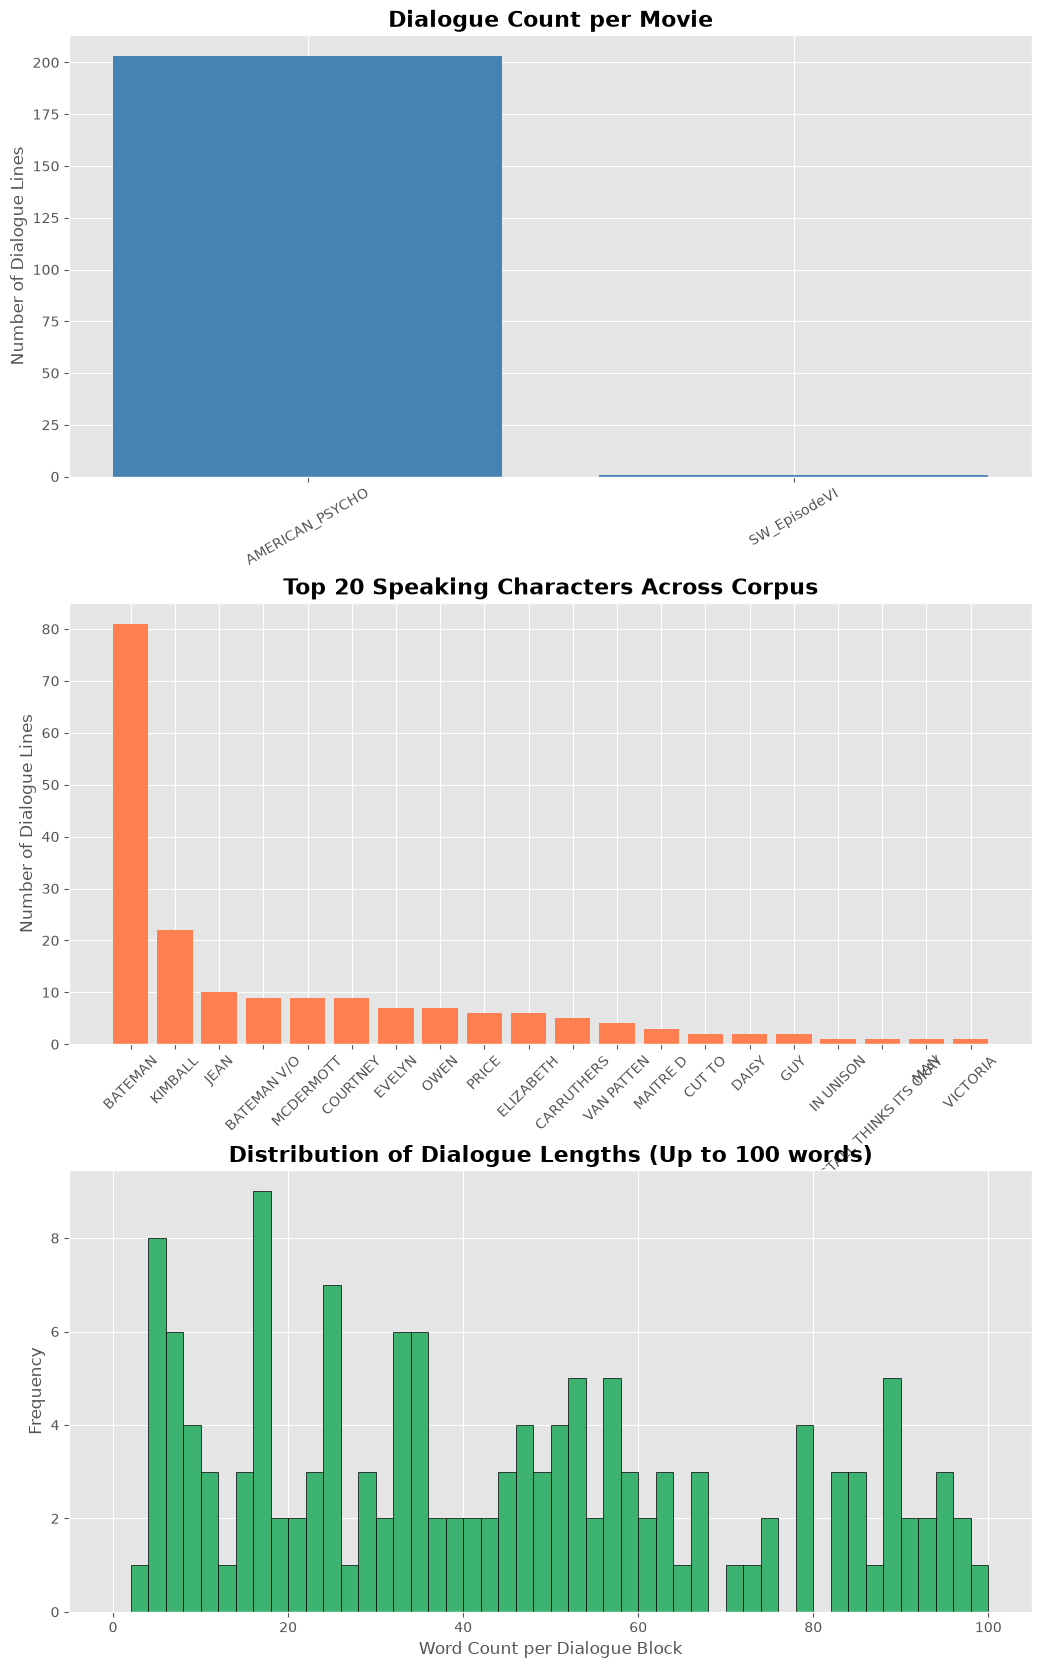

First 20 extracted dialogues:


,Movie,Scene,Character,Dialogue
0,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,BATEMAN V/O,...with goat cheese profiteroles and i also ha...
1,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,MCDERMOTT,you'll notice that my friends and i all look a...
2,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,MCDERMOTT,you think so? you'll look like you consciously...
3,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,MCDERMOTT,that s paul owen. that's not paul owen. paul o...
4,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,VAN PATTEN,"you spin a dreidel, mcdermott, not a menorah. ..."
5,AMERICAN_PSYCHO,INT. LIMOUSINE - NIGHT,VAN PATTEN,last week i picked up this vassar chick
6,AMERICAN_PSYCHO,INT. LIMOUSINE - NIGHT,MCDERMOTT,but i never told you what happened afterwards....
7,AMERICAN_PSYCHO,INT. LIMOUSINE - NIGHT,IN UNISON,never date a vassar girl.
8,AMERICAN_PSYCHO,EXT. 'TUNNEL'NIGHTCLUB - NIGHT,PRICE,"i suppose he doesn't want the car. price, ask ..."
9,AMERICAN_PSYCHO,"INT. LADIES ROOM,TUNNEL - NIGHT",PRICE,"i'm not sure, guy, but i don't think dyslexia ..."


In [5]:
# %% [markdown]
# # 01 - Data Preprocessing
# **Project:** AI-Based Media Empathy Analyzer  
# **Objective:** Parse raw screenplay `.txt` files, extract structured dialogues, clean text, and perform exploratory data analysis (EDA).
# 
# *This notebook is formatted using the standard `# %%` cell markers for seamless integration into Jupyter and VS Code environments.*

# %% [markdown]
# ## 1. Imports

# %%
import re
import warnings
from collections import Counter
from pathlib import Path
from typing import List, Dict, Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Suppress minor warnings for clean output
warnings.filterwarnings('ignore')

# %% [markdown]
# ## 2. Configuration

# %%
# Define base directory using a raw string for Windows path compatibility
BASE_DIR = Path(r"D:\project\NLP")

# Based on project structure, text files are in the main base directory
RAW_DATA_DIR = BASE_DIR

# Define directory path for processed outputs
PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"
OUTPUT_FILE = PROCESSED_DATA_DIR / "dialogues.csv"

# Create processed directory if it doesn't exist
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# %% [markdown]
# ## 3. Functions

# %%
def is_page_number_or_copyright(line: str) -> bool:
    """
    Detects if a line is a page number, formatting artifact, or copyright text.
    
    Args:
        line (str): The text line to evaluate.
        
    Returns:
        bool: True if the line matches unwanted patterns, False otherwise.
    """
    # Page numbers like '1.', '1', '(1)', '[1]'
    if re.match(r'^(?:\d{1,3}\.?|\[?\d{1,3}\]?|\(\d{1,3}\))$', line):
        return True
    
    # Copyright or rights text
    if re.search(r'(copyright|©|all rights reserved)', line, re.IGNORECASE):
        return True
        
    return False

def clean_character_name(line: str) -> str:
    """
    Cleans a character name line by stripping parentheticals (e.g., (V.O.), (CONT'D)).
    
    Args:
        line (str): The raw character name line.
        
    Returns:
        str: The cleaned character name.
    """
    # Remove parenthetical extensions like (V.O.) or (CONT'D)
    cleaned = re.sub(r'\(.*?\)', '', line).strip()
    # Remove unwanted trailing/leading punctuation
    cleaned = re.sub(r'[^A-Z0-9\s\-/]', '', cleaned).strip()
    return cleaned

def clean_dialogue_text(text: str) -> str:
    """
    Cleans dialogue by lowercasing, removing extra spaces, and preserving NLP punctuation.
    
    Args:
        text (str): The raw dialogue text.
        
    Returns:
        str: The cleaned dialogue text.
    """
    # Remove inline parentheticals (usually actor directions like '(sighs)')
    text = re.sub(r'\(.*?\)', '', text)
    # Lowercase
    text = text.lower()
    # Preserve only alphanumeric, spaces, and punctuation useful for NLP (. , ! ? ' ")
    text = re.sub(r'[^a-z0-9\s\.,!\?\'\"]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def parse_screenplay(file_path: Path) -> List[Dict[str, str]]:
    """
    Parses a screenplay text file and extracts structured dialogues.
    
    Automatically detects scene headings, character names, and dialogue,
    while implicitly ignoring action/scene descriptions based on screenplay structure.
    
    Args:
        file_path (Path): Path to the `.txt` screenplay file.
        
    Returns:
        List[Dict[str, str]]: A list of dictionaries containing Movie, Scene, Character, and Dialogue.
    """
    extracted_data = []
    movie_name = file_path.stem
    current_scene = "UNKNOWN_SCENE"
    current_character: Optional[str] = None
    current_dialogue_block: List[str] = []

    try:
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()
    except Exception as e:
        print(f"Error reading {file_path.name}: {e}")
        return []

    for line in lines:
        line = line.strip()

        # 1. Handle empty lines (used to denote the end of a speaking or action block)
        if not line:
            if current_character and current_dialogue_block:
                extracted_data.append({
                    'Movie': movie_name,
                    'Scene': current_scene,
                    'Character': current_character,
                    'Dialogue': " ".join(current_dialogue_block)
                })
                current_dialogue_block = []
            current_character = None  # Reset character tracking on block end
            continue

        # 2. Ignore page numbers, artifacts, and copyright
        if is_page_number_or_copyright(line):
            continue

        # 3. Detect Scene Headings
        if re.match(r'^(?:INT\.|EXT\.|INT/EXT\.|INT |EXT |I/E ).*', line, re.IGNORECASE):
            current_scene = line
            current_character = None
            continue

        # 4. Detect Transitions
        if re.match(r'.*(?:CUT TO:|FADE IN:|FADE OUT\.|DISSOLVE TO:)$', line):
            current_character = None
            continue

        # 5. Detect Character Names (Screenplay format standard is ALL CAPS)
        if line.isupper() and not re.search(r'[a-z]', line):
            char_name = clean_character_name(line)
            if len(char_name) > 1:  # Ignore stray single letters
                current_character = char_name
            continue

        # 6. Dialogue or Scene Description (Action)
        if current_character:
            # If a character was recently declared, this text belongs to their dialogue
            current_dialogue_block.append(line)
        else:
            # If no character is active, this is a scene description/action line. We skip it.
            pass

    # Catch any trailing dialogue at EOF
    if current_character and current_dialogue_block:
        extracted_data.append({
            'Movie': movie_name,
            'Scene': current_scene,
            'Character': current_character,
            'Dialogue': " ".join(current_dialogue_block)
        })

    return extracted_data

# %% [markdown]
# ## 4. Loading Scripts & Parsing

# %%
all_extracted_data = []
# Look for text files directly in the RAW_DATA_DIR (which is now your root NLP folder)
script_files = list(RAW_DATA_DIR.glob("*.txt"))

if not script_files:
    print(f"No .txt files found in {RAW_DATA_DIR}. Please ensure raw scripts are placed in this directory.")
else:
    print(f"Found {len(script_files)} script(s). Beginning parsing...")
    
    for file_path in tqdm(script_files, desc="Parsing Screenplays"):
        parsed_script = parse_screenplay(file_path)
        all_extracted_data.extend(parsed_script)

# Create the initial raw DataFrame
raw_df = pd.DataFrame(all_extracted_data)

# %% [markdown]
# ## 5. Cleaning

# %%
if not raw_df.empty:
    print("Cleaning extracted dialogues...")
    
    # Create a working copy for the cleaned dataset
    df = raw_df.copy()
    
    # Apply cleaning function to dialogue column
    df['Dialogue'] = df['Dialogue'].apply(clean_dialogue_text)
    
    # Drop rows where dialogue became completely empty after cleaning out artifacts/parentheticals
    df = df[df['Dialogue'].str.strip() != '']
    
    # Reset index for a clean continuum
    df.reset_index(drop=True, inplace=True)
    print("Cleaning complete.")
else:
    df = pd.DataFrame(columns=['Movie', 'Scene', 'Character', 'Dialogue'])
    print("DataFrame is empty. Skipping cleaning.")

# %% [markdown]
# ## 6. Saving

# %%
if not df.empty:
    df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8')
    print(f"Data successfully saved to: {OUTPUT_FILE}")
else:
    print("No data to save.")

# %% [markdown]
# ## 7. EDA (Exploratory Data Analysis) - Summary

# %%
if not df.empty:
    print("="*50)
    print("DATASET SUMMARY")
    print("="*50)
    
    num_movies = df['Movie'].nunique()
    num_scenes = df['Scene'].nunique()
    num_dialogues = len(df)
    num_characters = df['Character'].nunique()
    
    print(f"Number of movies:            {num_movies}")
    print(f"Number of scenes:            {num_scenes}")
    print(f"Number of dialogues:         {num_dialogues}")
    print(f"Number of unique characters: {num_characters}")
    print("-" * 50)
    
    print("Top 20 most frequent characters:")
    top_20_chars = df['Character'].value_counts().head(20)
    for char, count in top_20_chars.items():
        print(f" - {char:<25} {count} lines")
    print("="*50)

# %% [markdown]
# ## 8. EDA - Visualizations

# %%
if not df.empty:
    # Set standard plot styling
    plt.style.use('ggplot')
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    fig.tight_layout(pad=7.0)

    # 1. Dialogue count per movie
    movie_counts = df['Movie'].value_counts()
    axes[0].bar(movie_counts.index, movie_counts.values, color='steelblue')
    axes[0].set_title('Dialogue Count per Movie', fontsize=16, fontweight='bold')
    axes[0].set_ylabel('Number of Dialogue Lines', fontsize=12)
    axes[0].tick_params(axis='x', rotation=30)

    # 2. Top speaking characters
    char_counts = df['Character'].value_counts().head(20)
    axes[1].bar(char_counts.index, char_counts.values, color='coral')
    axes[1].set_title('Top 20 Speaking Characters Across Corpus', fontsize=16, fontweight='bold')
    axes[1].set_ylabel('Number of Dialogue Lines', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45)

    # 3. Histogram of dialogue lengths
    # Calculate word count for each dialogue line on the fly
    df['Word_Count'] = df['Dialogue'].apply(lambda x: len(str(x).split()))
    
    axes[2].hist(df['Word_Count'], bins=50, range=(0, 100), color='mediumseagreen', edgecolor='black')
    axes[2].set_title('Distribution of Dialogue Lengths (Up to 100 words)', fontsize=16, fontweight='bold')
    axes[2].set_xlabel('Word Count per Dialogue Block', fontsize=12)
    axes[2].set_ylabel('Frequency', fontsize=12)

    plt.show()

# %% [markdown]
# ## 9. Review Extracted Data

# %%
if not df.empty:
    print("First 20 extracted dialogues:")
    # Drop Word_Count column to strictly match requested DataFrame output format
    display_df = df.drop(columns=['Word_Count'], errors='ignore')
    
    # In a notebook environment, display renders the HTML table
    display(display_df.head(20))